In [1]:
# %pip install pandas numpy matplotlib seaborn scikit-learn joblib sqlalchemy requests schedule
import pandas as pd
from scipy.stats import zscore
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import joblib
import io
import time
import requests
from sqlalchemy import create_engine, MetaData, Table, Column, Integer, Float
import json
from datetime import datetime, timedelta
import datetime
import logging
import schedule
# %pip install mysql-connector-python
import mysql.connector
# from airflow import DAG
# from airflow.operators.python import PythonOperator
# from airflow.exceptions import AirflowException
import os

# %pip install kaggle

import kaggle

In [2]:
connection_parms = {'username' : 'root',
'password' : 'Kingfisher262326',
# localhost = 'localhost:3306'
'port' : '3306',
'host' : 'localhost'}

## Business Problem

### Problem Statement
The bank is experiencing a high rate of customer churn, which is negatively impacting its revenue and profitability. Customer churn refers to the phenomenon where customers stop doing business with the bank. Understanding the factors that contribute to customer churn and predicting which customers are likely to churn can help the bank take proactive measures to retain them.

### Key Business Objective
The primary objective is to develop a predictive model that can accurately identify customers who are at risk of churning. By doing so, the bank can implement targeted retention strategies to reduce the churn rate, thereby increasing customer loyalty and maximizing revenue.

### Key data source
Data source we have selected is CSV file and Kaggle API. but we are working on only one CSV file.  
'RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',        'IsActiveMember', 'EstimatedSalary', 'Exited'

### Exploratory Data Analysis (EDA)
1. **Summary Statistics**: Descriptive statistics for numerical features, including mean, median, standard deviation, min, and max values.
2. **Distribution Plots**: Histograms and KDE plots for numerical features to visualize their distributions.
3. **Categorical Feature Distribution**: Count plots for categorical features to understand the frequency of each category.
4. **Correlation Matrix**: Heatmap showing the correlation between numerical features to identify potential relationships.
5. **Box Plots**: Box plots for numerical features to identify outliers.
6. **Pair Plot**: Pair plot to visualize relationships between features and the target variable (`Exited`).

### Feature Transformation
1. **Standardization**: Numerical features are standardized to have a mean of 0 and a standard deviation of 1.
2. **One-Hot Encoding**: Categorical features are encoded using one-hot encoding to convert them into numerical format.
3. **Aggregated Features**: New features are created based on aggregated statistics (e.g., mean salary by gender, mean balance by geography).
4. **Derived Features**: Additional features are derived from existing ones (e.g., tenure standardized by age).

### Model Building and Evaluation
1. **Model Training**: Multiple models (Logistic Regression, Random Forest, Decision Tree, SVM) are trained on the transformed dataset.
2. **Model Evaluation**: Each model is evaluated using metrics such as accuracy, precision, recall, and F1-score.
3. **Confusion Matrix**: Confusion matrix for each model to visualize the performance in terms of true positives, true negatives, false positives, and false negatives.
4. **Performance Report**: A summary report comparing the performance of all models, highlighting the best-performing model.
5. **Model Saving**: The best-performing model is saved for future predictions.


These outputs ensure that the data is thoroughly analyzed, transformed, and used to build accurate predictive models for customer churn, with proper data management and storage practices in place.

In the context of our classification machine learning, measurable evaluation metrics are used to assess the performance of a model. Here are some common evaluation metrics:

1. **Accuracy**:
    - **Definition**: The ratio of correctly predicted instances to the total instances.
    
2. **Precision**:
    - **Definition**: The ratio of correctly predicted positive observations to the total predicted positives.

3. **Recall (Sensitivity or True Positive Rate)**:
    - **Definition**: The ratio of correctly predicted positive observations to all the observations in the actual class.

4. **F1-Score**:
    - **Definition**: The weighted average of Precision and Recall.

5. **Confusion Matrix**:
    - **Definition**: A table used to describe the performance of a classification model.
    - **Components**:
      - **TP (True Positive)**: Correctly predicted positive instances.
      - **TN (True Negative)**: Correctly predicted negative instances.
      - **FP (False Positive)**: Incorrectly predicted positive instances.
      - **FN (False Negative)**: Incorrectly predicted negative instances.

6. **ROC-AUC (Receiver Operating Characteristic - Area Under Curve)**:
    - **Definition**: A graphical representation of the true positive rate against the false positive rate at various threshold settings.

These metrics help in understanding the strengths and weaknesses of a model and guide in improving its performance.

In [3]:
# # EDA
# # Summary Statistics
# print("Summary Statistics:\n", df.describe())

# # Distribution of Numerical Features
# numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
# for column in numerical_columns:
#     plt.figure(figsize=(5, 3))
#     sns.histplot(df[column], kde=True)
#     plt.title(f'Distribution of {column}')
#     plt.show()

# # Distribution of Categorical Features
# categorical_columns = df.select_dtypes(include=['object']).columns
# for column in categorical_columns:
#     plt.figure(figsize=(5, 3))
#     sns.countplot(x=df[column])
#     plt.title(f'Distribution of {column}')
#     plt.show()

# # Correlation Matrix
# plt.figure(figsize=(12, 8))
# corr_matrix = df.corr()
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
# plt.title('Correlation Matrix')
# plt.show()

# # Box Plots for Outliers
# for column in numerical_columns:
#     plt.figure(figsize=(5, 3))
#     sns.boxplot(x=df[column])
#     plt.title(f'Box Plot of {column}')
#     plt.show()

# # Pair Plot
# sns.pairplot(df, diag_kind='kde', hue='Exited')
# plt.title('Pair Plot')
# plt.show()

# # Feature Transformation
# # Standardization of numerical features
# scaler = StandardScaler()
# df_scaled = df.copy()
# df_scaled[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# # One-hot encoding of categorical features
# df_encoded = pd.get_dummies(df_scaled, columns=categorical_columns, drop_first=True)

# # Creation of aggregated and derived features
# df_encoded['Gender_mean_salary'] = df.groupby('Gender')['EstimatedSalary'].transform('mean')
# df_encoded['Geography_mean_salary'] = df.groupby('Geography')['EstimatedSalary'].transform('mean')
# df_encoded['Age_mean_salary'] = df_encoded.groupby('Age')['EstimatedSalary'].transform('mean')
# df_encoded['Gender_mean_balance'] = df.groupby('Gender')['Balance'].transform('mean')
# df_encoded['Geography_mean_balance'] = df.groupby('Geography')['Balance'].transform('mean')
# df_encoded['Age_mean_balance'] = df_encoded.groupby('Age')['Balance'].transform('mean')
# df_encoded["NewTenure"] = df_encoded["Tenure"] / df["Age"]

# # Model Building and Evaluation
# x = df_encoded.drop(['Exited'], axis=1)
# y = df_encoded['Exited']
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# # Train models
# models = {
#     'Logistic Regression': LogisticRegression(),
#     'Random Forest': RandomForestClassifier(),
#     'Decision Tree': DecisionTreeClassifier(),
#     'SVM': SVC()
# }

# performance_report = {
#     'Model': [],
#     'Accuracy': [],
#     'Precision': [],
#     'Recall': [],
#     'F1-Score': []
# }

# for name, model in models.items():
#     model.fit(x_train, y_train)
#     y_pred = model.predict(x_test)
#     performance_report['Model'].append(name)
#     performance_report['Accuracy'].append(accuracy_score(y_test, y_pred))
#     performance_report['Precision'].append(classification_report(y_test, y_pred, output_dict=True)['1']['precision'])
#     performance_report['Recall'].append(classification_report(y_test, y_pred, output_dict=True)['1']['recall'])
#     performance_report['F1-Score'].append(classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'])

# # Convert the dictionary to a DataFrame for better visualization
# performance_df = pd.DataFrame(performance_report)

# # Display the performance report
# print(performance_df)

# # Save the best-performing model
# best_model_name = performance_df.loc[performance_df['Accuracy'].idxmax(), 'Model']
# best_model = models[best_model_name]
# joblib.dump(best_model, f'{best_model_name.lower().replace(" ", "_")}_model.pkl')

## Data Ingestion

Two Data sources identified for our analysis are as follows:
1. Bank customer churn as CSV file
2. Employee churn from Kaggle using API.

Script for data ingestion and automatic fetching of data periodically with logging and error handling

In [4]:
# Configure logging
logging.basicConfig(filename='data_ingestion.log', level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

kaggle_dir = 'data/employee_churn'
csv_data_dir = 'data/bank_customer_churn'

# Create the directory if it doesn't exist
if not os.path.exists(kaggle_dir):
    os.makedirs(kaggle_dir)
    print(f"Directory {kaggle_dir} created successfully.")
else:
    print(f"Directory {kaggle_dir} already exists.")

if not os.path.exists(csv_data_dir):
    os.makedirs(csv_data_dir)
    print(f"Directory {csv_data_dir} created successfully.")
else:
    print(f"Directory {csv_data_dir} already exists.")

# Function to fetch data from CSV file
def fetch_csv_data():
    try:
        df_csv = pd.read_csv(csv_data_dir+'/'+ 'churn.csv')
        logging.info("CSV Data Source Loaded Successfully")
        return df_csv
    except Exception as e:
        logging.error(f"Failed to load CSV Data Source: {e}")
        return None

# Function to fetch data from API
def fetch_api_data():
    try:
        kaggle.api.authenticate()
        kaggle.api.dataset_download_files("jixiangruyi/predict-employee-left", path='data/employee_churn', unzip=True)
        df_api = pd.read_csv("data/employee_churn/data/HR_dataset.csv")
        logging.info("Kaggle Data Source Loaded Successfully")
        return df_api
    except Exception as e:
        logging.error(f"Failed to load API Data Source: {e}")
        return None

def ingest_data():
    logging.info("Starting data ingestion process")
    df_csv = fetch_csv_data()
    df_api = fetch_api_data()
    
    if df_csv is not None:
        logging.info("CSV Data Ingested Successfully")
    if df_api is not None:
        logging.info("API Data Ingested Successfully")

    logging.info("Data ingestion process completed")

# Schedule the ingestion job to run daily at a specific time
schedule.every().day.at("00:00").do(ingest_data)

# Keep the script running
# while True:
#     schedule.run_pending()
#     time.sleep(1)

Directory data/employee_churn already exists.
Directory data/bank_customer_churn already exists.


Every 1 day at 00:00:00 do ingest_data() (last run: [never], next run: 2025-03-13 00:00:00)

In [5]:
df_csv = fetch_csv_data()
df_api = fetch_api_data()

Dataset URL: https://www.kaggle.com/datasets/jixiangruyi/predict-employee-left


In [6]:
# # Initialize the S3 client
# s3_client = boto3.client('s3')

# # Define the S3 bucket name
# bucket_name = 'your-bucket-name'

# # Define the folder structure
# def get_s3_key(source, data_type, timestamp):
#     return f"{source}/{data_type}/{timestamp.strftime('%Y/%m/%d')}/data.csv"

# # Upload data to S3
# def upload_to_s3(df, source, data_type):
#     timestamp = datetime.now()
#     s3_key = get_s3_key(source, data_type, timestamp)
#     csv_buffer = io.BytesIO()
#     df.to_csv(csv_buffer, index=False)
#     s3_client.put_object(Bucket=bucket_name, Key=s3_key, Body=csv_buffer.getvalue())
#     print(f"Data uploaded to S3: s3://{bucket_name}/{s3_key}")

# # Example usage
# upload_to_s3(df_csv, 'csv_source', 'raw')
# upload_to_s3(df_api, 'api_source', 'raw')
# upload_to_s3(df_db, 'db_source', 'raw')

## Raw Data Storage

In [7]:
# Define the base directory for storing data
base_dir = 'data_storage'

# Create the base directory if it doesn't exist
if not os.path.exists(base_dir):
    os.makedirs(base_dir)

# Define the folder structure
def get_local_path(source, data_type, timestamp):
    return os.path.join(base_dir, source, data_type, timestamp.strftime('%Y/%m/%d'), 'data.csv')

# Save data to local filesystem
def save_to_local(df, source, data_type):
    timestamp = datetime.datetime.now()
    local_path = get_local_path(source, data_type, timestamp)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    df.to_csv(local_path, index=False)
    print(f"Data saved to local filesystem: {local_path}")

# Example usage
save_to_local(df_csv, 'csv_source', 'raw')
save_to_local(df_api, 'api_source', 'raw')


Data saved to local filesystem: data_storage\csv_source\raw\2025/03/12\data.csv
Data saved to local filesystem: data_storage\api_source\raw\2025/03/12\data.csv


## Folder/Bucket Structure Documentation

### Local Filesystem Structure
The local filesystem is organized similarly to the S3 bucket, with a base directory for storing data from different sources and types, and a timestamped folder structure.

- **Base Directory**: `data_storage`
- **Folder Structure**:
    - `source/`
        - `data_type/`
            - `YYYY/`
                - `MM/`
                    - `DD/`
                        - `data.csv`

#### Example:
- `data_storage/csv_source/raw/2025/03/12/data.csv`
- `data_storage/api_source/raw/2023/03/12/data.csv`


### Explanation:
- **source**: The origin of the data (e.g., `csv_source`, `api_source`, `db_source`).
- **data_type**: The type of data being stored (e.g., `raw`, `processed`).
- **YYYY/MM/DD**: The year, month, and day when the data was ingested or processed.
- **data.csv**: The actual data file in CSV format.

In [8]:
# Define the paths to the stored data files
csv_file_path = 'data_storage/csv_source/raw/2025/03/12/data.csv'
api_file_path = 'data_storage/api_source/raw/2025/03/12/data.csv'

# Read the data from the local file system
df_csv_local = pd.read_csv(csv_file_path)
df_api_local = pd.read_csv(api_file_path)

# Display the first few rows of each dataframe
print("CSV Data:\n", df_csv_local.head())
print("API Data:\n", df_api_local.head())

CSV Data:
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4 

In [9]:
df = df_csv_local.copy()
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data validation

### Check for missing data

In [10]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

We can see in this dataset we dont have any missing value.

### Validate data types, formats, and ranges

In [11]:
print("Data Types: \n", df.dtypes)

Data Types: 
 RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


#### Check for the Invalid Formats

For example, if a column should contain dates, ensure they are in the correct format. in our dataset there is no date column.

In [12]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [13]:
# Example: Check if 'numeric_column' contains only numeric values
invalid_columns = []
for col in numerical_cols:
    if not pd.api.types.is_numeric_dtype(df[col]):
        invalid_columns.append(col)

if not invalid_columns:
    print("All numeric columns format are valid.")
else:
    print(f"Invalid numeric column formats: {invalid_columns}")

All numeric columns format are valid.


In [14]:
# Example: Check if 'categorical_column' contains only expected categories
expected_categories = {
    'Geography': ['France', 'Spain', 'Germany'],
    'Gender': ['Male', 'Female']
}

invalid_categories = []
for col in categorical_cols:
    if col in expected_categories:
        if not df[col].isin(expected_categories[col]).all():
            invalid_categories.append(col)

if not invalid_categories:
    print("All categorical columns format are valid.")
else:
    print(f"Invalid categorical column formats: {invalid_categories}")


All categorical columns format are valid.


#### Check for valid Range

In [15]:
expected_ranges = {
    'Age': (18, 100),  # Example: Age should be between 18 and 100
    'EstimatedSalary': (0, 1000000),  # Example: Salary should be between 0 and 1,000,000
    'CreditScore': (300, 900),  # Example: Credit Score should be between 300 and 900
    'Tenure': (0, 50),  # Example: Tenure should be between 0 and 50
    'Balance': (0, 1000000),  # Example: Balance should be between 0 and 1,000,000
    'NumOfProducts': (1, 4),  # Example: NumOfProducts should be between 1 and 4
    'HasCrCard': (0, 1),  # Example: HasCrCard should be either 0 or 1
    'IsActiveMember': (0, 1),  # Example: IsActiveMember should be either 0 or 1
    'Exited': (0, 1),  # Example: Exited should be either 0 or 1
}

In [16]:
for column, (min_val, max_val) in expected_ranges.items():
    if not df[column].between(min_val, max_val).all():
        print(f"Values in column '{column}' are out of the expected range ({min_val}, {max_val}).")
    else:
        print(f"Values in column '{column}' are within the expected range ({min_val}, {max_val}).")


Values in column 'Age' are within the expected range (18, 100).
Values in column 'EstimatedSalary' are within the expected range (0, 1000000).
Values in column 'CreditScore' are within the expected range (300, 900).
Values in column 'Tenure' are within the expected range (0, 50).
Values in column 'Balance' are within the expected range (0, 1000000).
Values in column 'NumOfProducts' are within the expected range (1, 4).
Values in column 'HasCrCard' are within the expected range (0, 1).
Values in column 'IsActiveMember' are within the expected range (0, 1).
Values in column 'Exited' are within the expected range (0, 1).


### Identify duplicate or anamolies

#### Identify Duplicate Rows

In [17]:
duplicate_rows = df[df.duplicated()]
print("Duplicate Rows:\n", duplicate_rows)

# Remove duplicate rows if available
df = df.drop_duplicates()

Duplicate Rows:
 Empty DataFrame
Columns: [RowNumber, CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited]
Index: []


#### Identify Anomalies

In [18]:
# Using statistical methods to identify anomalies

z_scores = df.select_dtypes(include=['float64', 'int64']).apply(zscore)

# Define a threshold for identifying anomalies (e.g., Z-score > 3 or < -3)
threshold = 3
anomalies = (z_scores > threshold) | (z_scores < -threshold)
anomalies = anomalies.any(axis=1)
anomalous_rows = df[anomalies]
anomalous_rows.head()
print("Anomalous Rows Count:\n", len(anomalous_rows))

# Remove the outliers from the dataframe
df_cleaned = df[~anomalies]
print("Dataframe after removing outliers:\n", len(df_cleaned))

Anomalous Rows Count:
 201
Dataframe after removing outliers:
 9799


Data Quality Report  
1. Missing Values  
Issue: Missing values were not identified in the dataset.   
Resolution: If missing values were identified we handled by filling numerical features with their median values and categorical features with their mode values.

2. Data Types  
Issue: Data types of columns were validated to ensure they are as expected.   
Resolution: in our dataset we don’t have the invalid data format, if available we can take necessary steps for conversions to ensure consistency.

3. Invalid Formats  
Issue: Columns were checked for invalid formats.
Numeric Column: Ensured that 'numeric_column' contains only numeric values. Using pd.api.types.is_numeric_dtype().
Categorical Column: Ensured that 'categorical_column' contains only expected categories. df['categorical_cols'].isin(expected_categories).all().  
4. Valid Ranges  
Issue: Numerical columns were checked to ensure values fall within expected ranges.  
Resolution: Defined expected ranges for numerical columns and validated that the values fall within these ranges using the between() method.  
5. Duplicate Rows  
Issue: Duplicate rows were identified in the dataset.   
Resolution: Duplicate rows were removed using df.drop_duplicates().

6. Anomalies  
Issue: Anomalies were identified using statistical methods and visualization techniques.
Z-score Method: Calculated Z-scores for numerical columns to identify anomalies.
Box Plots: Visualized numerical columns using box plots to identify outliers visually.  
Resolution:   
Z-score Method: Rows with Z-scores greater than 3 or less than -3 were considered anomalous and flagged for further investigation.
Box Plots: Outliers were visually identified and flagged for further investigation.


## Data Preparation

### Clean and Preprocess the raw data

* Handling MIssing Values:

In [19]:
df_cleaned.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

As our data does not contains any missing values so no need for handling it.

* Standarize the numerical attributes

In [20]:
df_cleaned.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [21]:
scaler = StandardScaler()
df_scaled = df_cleaned.copy()
df_scaled[numerical_cols[2:-1]] = scaler.fit_transform(df_cleaned[numerical_cols[2:-1]])
print(df_scaled.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender       Age  \
0          1    15634602  Hargrave    -0.327879    France  Female  0.374169   
1          2    15647311      Hill    -0.442063     Spain  Female  0.270681   
2          3    15619304      Onio    -1.542374    France  Female  0.374169   
3          4    15701354      Boni     0.502545    France  Female  0.063705   
4          5    15737888  Mitchell     2.069970     Spain  Female  0.477658   

     Tenure   Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0 -1.041776 -1.225443      -0.935749   0.646281        0.980094   
1 -1.387705  0.117543      -0.935749  -1.547314        0.980094   
2  1.033798  1.333055       2.694979   0.646281       -1.020310   
3 -1.387705 -1.225443       0.879615  -1.547314       -1.020310   
4 -1.041776  0.785816      -0.935749   0.646281        0.980094   

   EstimatedSalary  Exited  
0         0.022951       1  
1         0.217648       0  
2         0.241807       1  
3     

We have removed the RowNumber and Customer id from encoding as these attributes will not add any significance in our analysis.

* Encode categorical valiables using one-hot encoding.

In [22]:
# Identify categorical columns
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns
categorical_columns[1:]

Index(['Geography', 'Gender'], dtype='object')

We have removed surname from our analysis because it will create very large sparse matrix and will cause overfitting of the model.

In [23]:
# Apply one-hot encoding
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_columns[1:], drop_first=True, dtype='int64')

# Display the first few rows of the encoded dataset
print(df_encoded.head())

   RowNumber  CustomerId   Surname  CreditScore  Age  Tenure    Balance  \
0          1    15634602  Hargrave          619   42       2       0.00   
1          2    15647311      Hill          608   41       1   83807.86   
2          3    15619304      Onio          502   42       8  159660.80   
3          4    15701354      Boni          699   39       1       0.00   
4          5    15737888  Mitchell          850   43       2  125510.82   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  \
0              1          1               1        101348.88       1   
1              1          0               1        112542.58       0   
2              3          1               0        113931.57       1   
3              2          0               0         93826.63       0   
4              1          1               1         79084.10       0   

   Geography_Germany  Geography_Spain  Gender_Male  
0                  0                0            0  
1         

### Perform EDA to identify trends, distributions and Outliers

In [24]:
# Summary Statistics
print("Summary Statistics:\n", df_cleaned.iloc[:, 3:-1].describe())

Summary Statistics:
        CreditScore          Age       Tenure        Balance  NumOfProducts  \
count  9799.000000  9799.000000  9799.000000    9799.000000    9799.000000   
mean    650.586693    38.384427     5.011532   76472.676347       1.515461   
std      96.341265     9.663426     2.890915   62407.290305       0.550882   
min     363.000000    18.000000     0.000000       0.000000       1.000000   
25%     584.000000    32.000000     3.000000       0.000000       1.000000   
50%     652.000000    37.000000     5.000000   97133.920000       1.000000   
75%     718.000000    43.000000     7.000000  127638.135000       2.000000   
max     850.000000    70.000000    10.000000  250898.090000       3.000000   

         HasCrCard  IsActiveMember  EstimatedSalary  
count  9799.000000     9799.000000      9799.000000  
mean      0.705378        0.510052    100029.359750  
std       0.455896        0.499924     57495.943704  
min       0.000000        0.000000        11.580000  
25%   

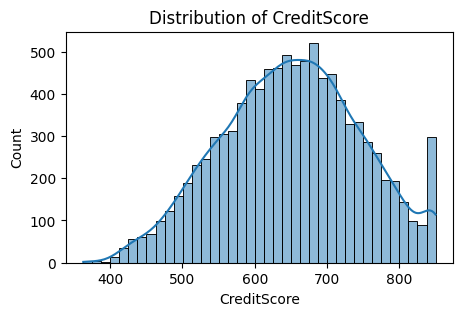

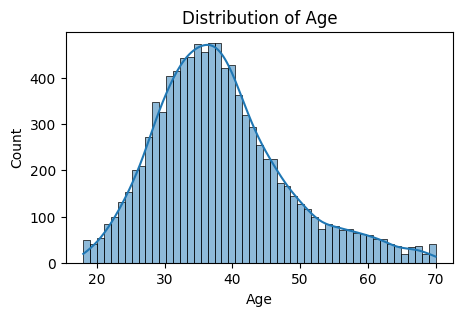

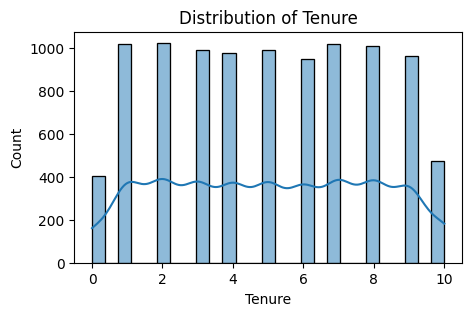

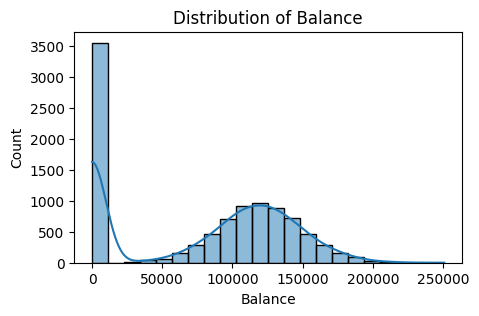

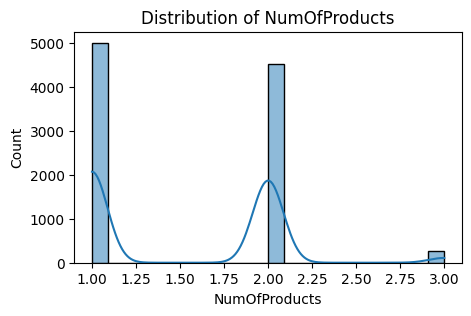

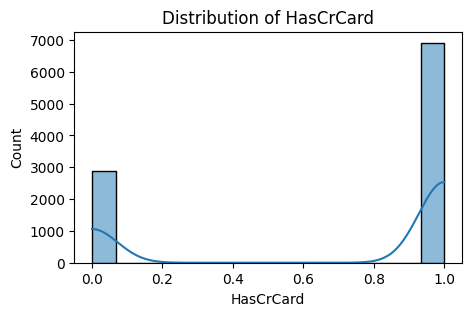

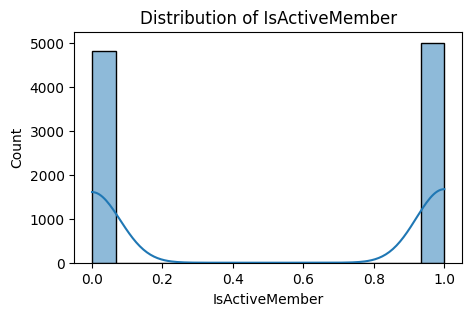

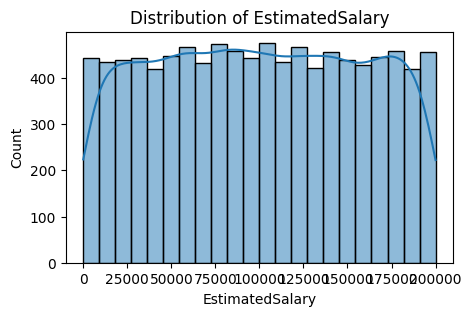

In [25]:
# Distribution of Numerical Features
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
for column in numerical_columns[2:-1]:
    plt.figure(figsize=(5, 3))
    sns.histplot(df_cleaned[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

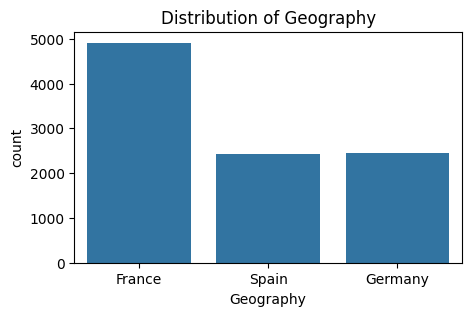

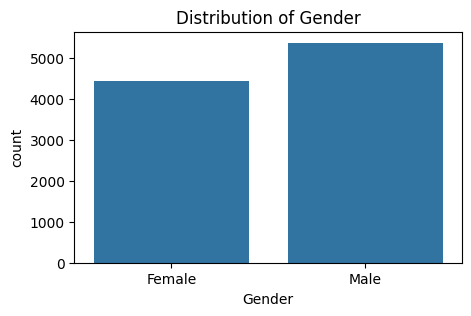

In [26]:
# Distribution of Categorical Features
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns
for column in categorical_columns[1:]:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df_cleaned[column])
    plt.title(f'Distribution of {column}')
    plt.show()

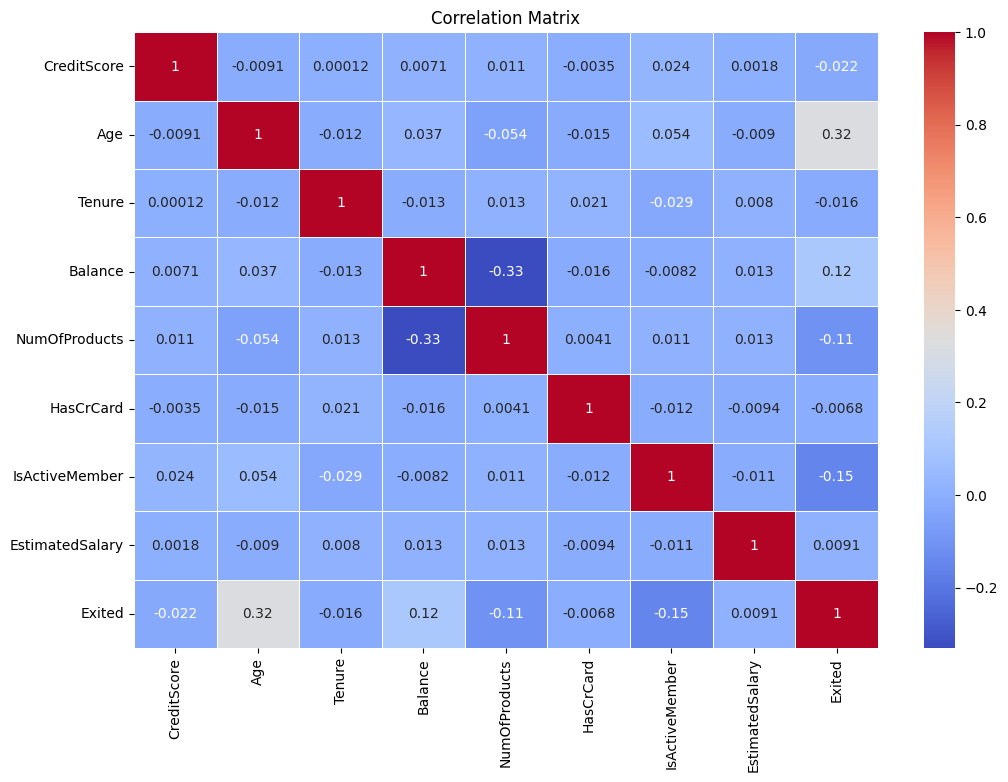

In [27]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
corr_matrix = df_cleaned[numerical_cols[2:]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

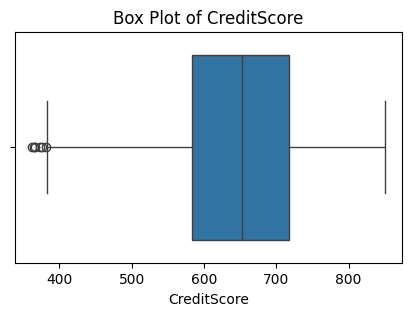

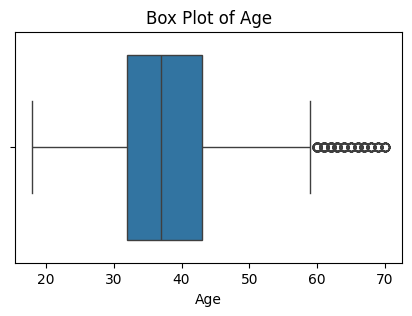

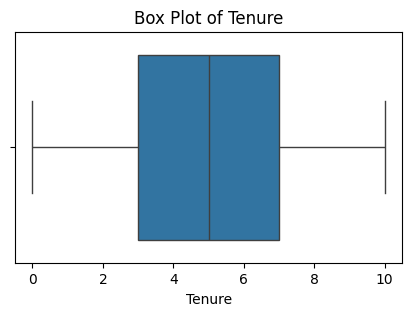

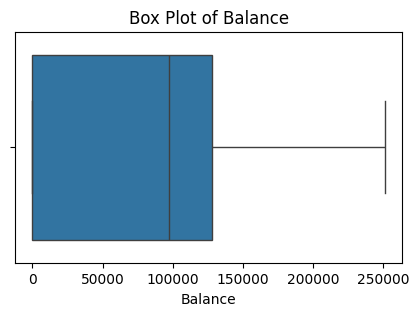

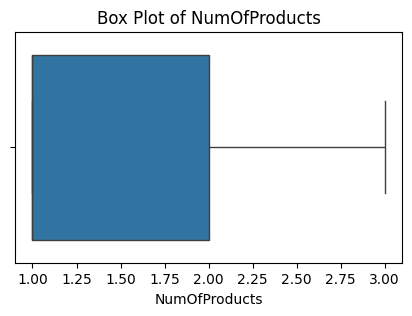

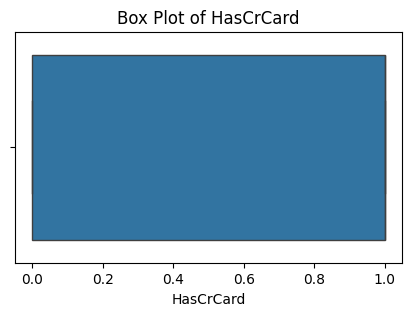

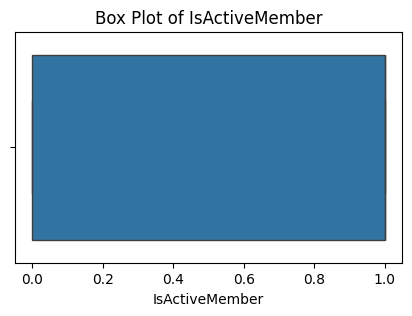

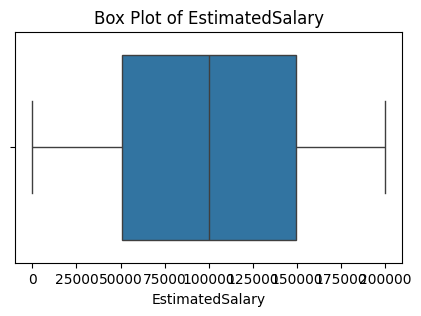

In [28]:
# Box Plots for Outliers
for column in numerical_columns[2:-1]:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df_cleaned[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

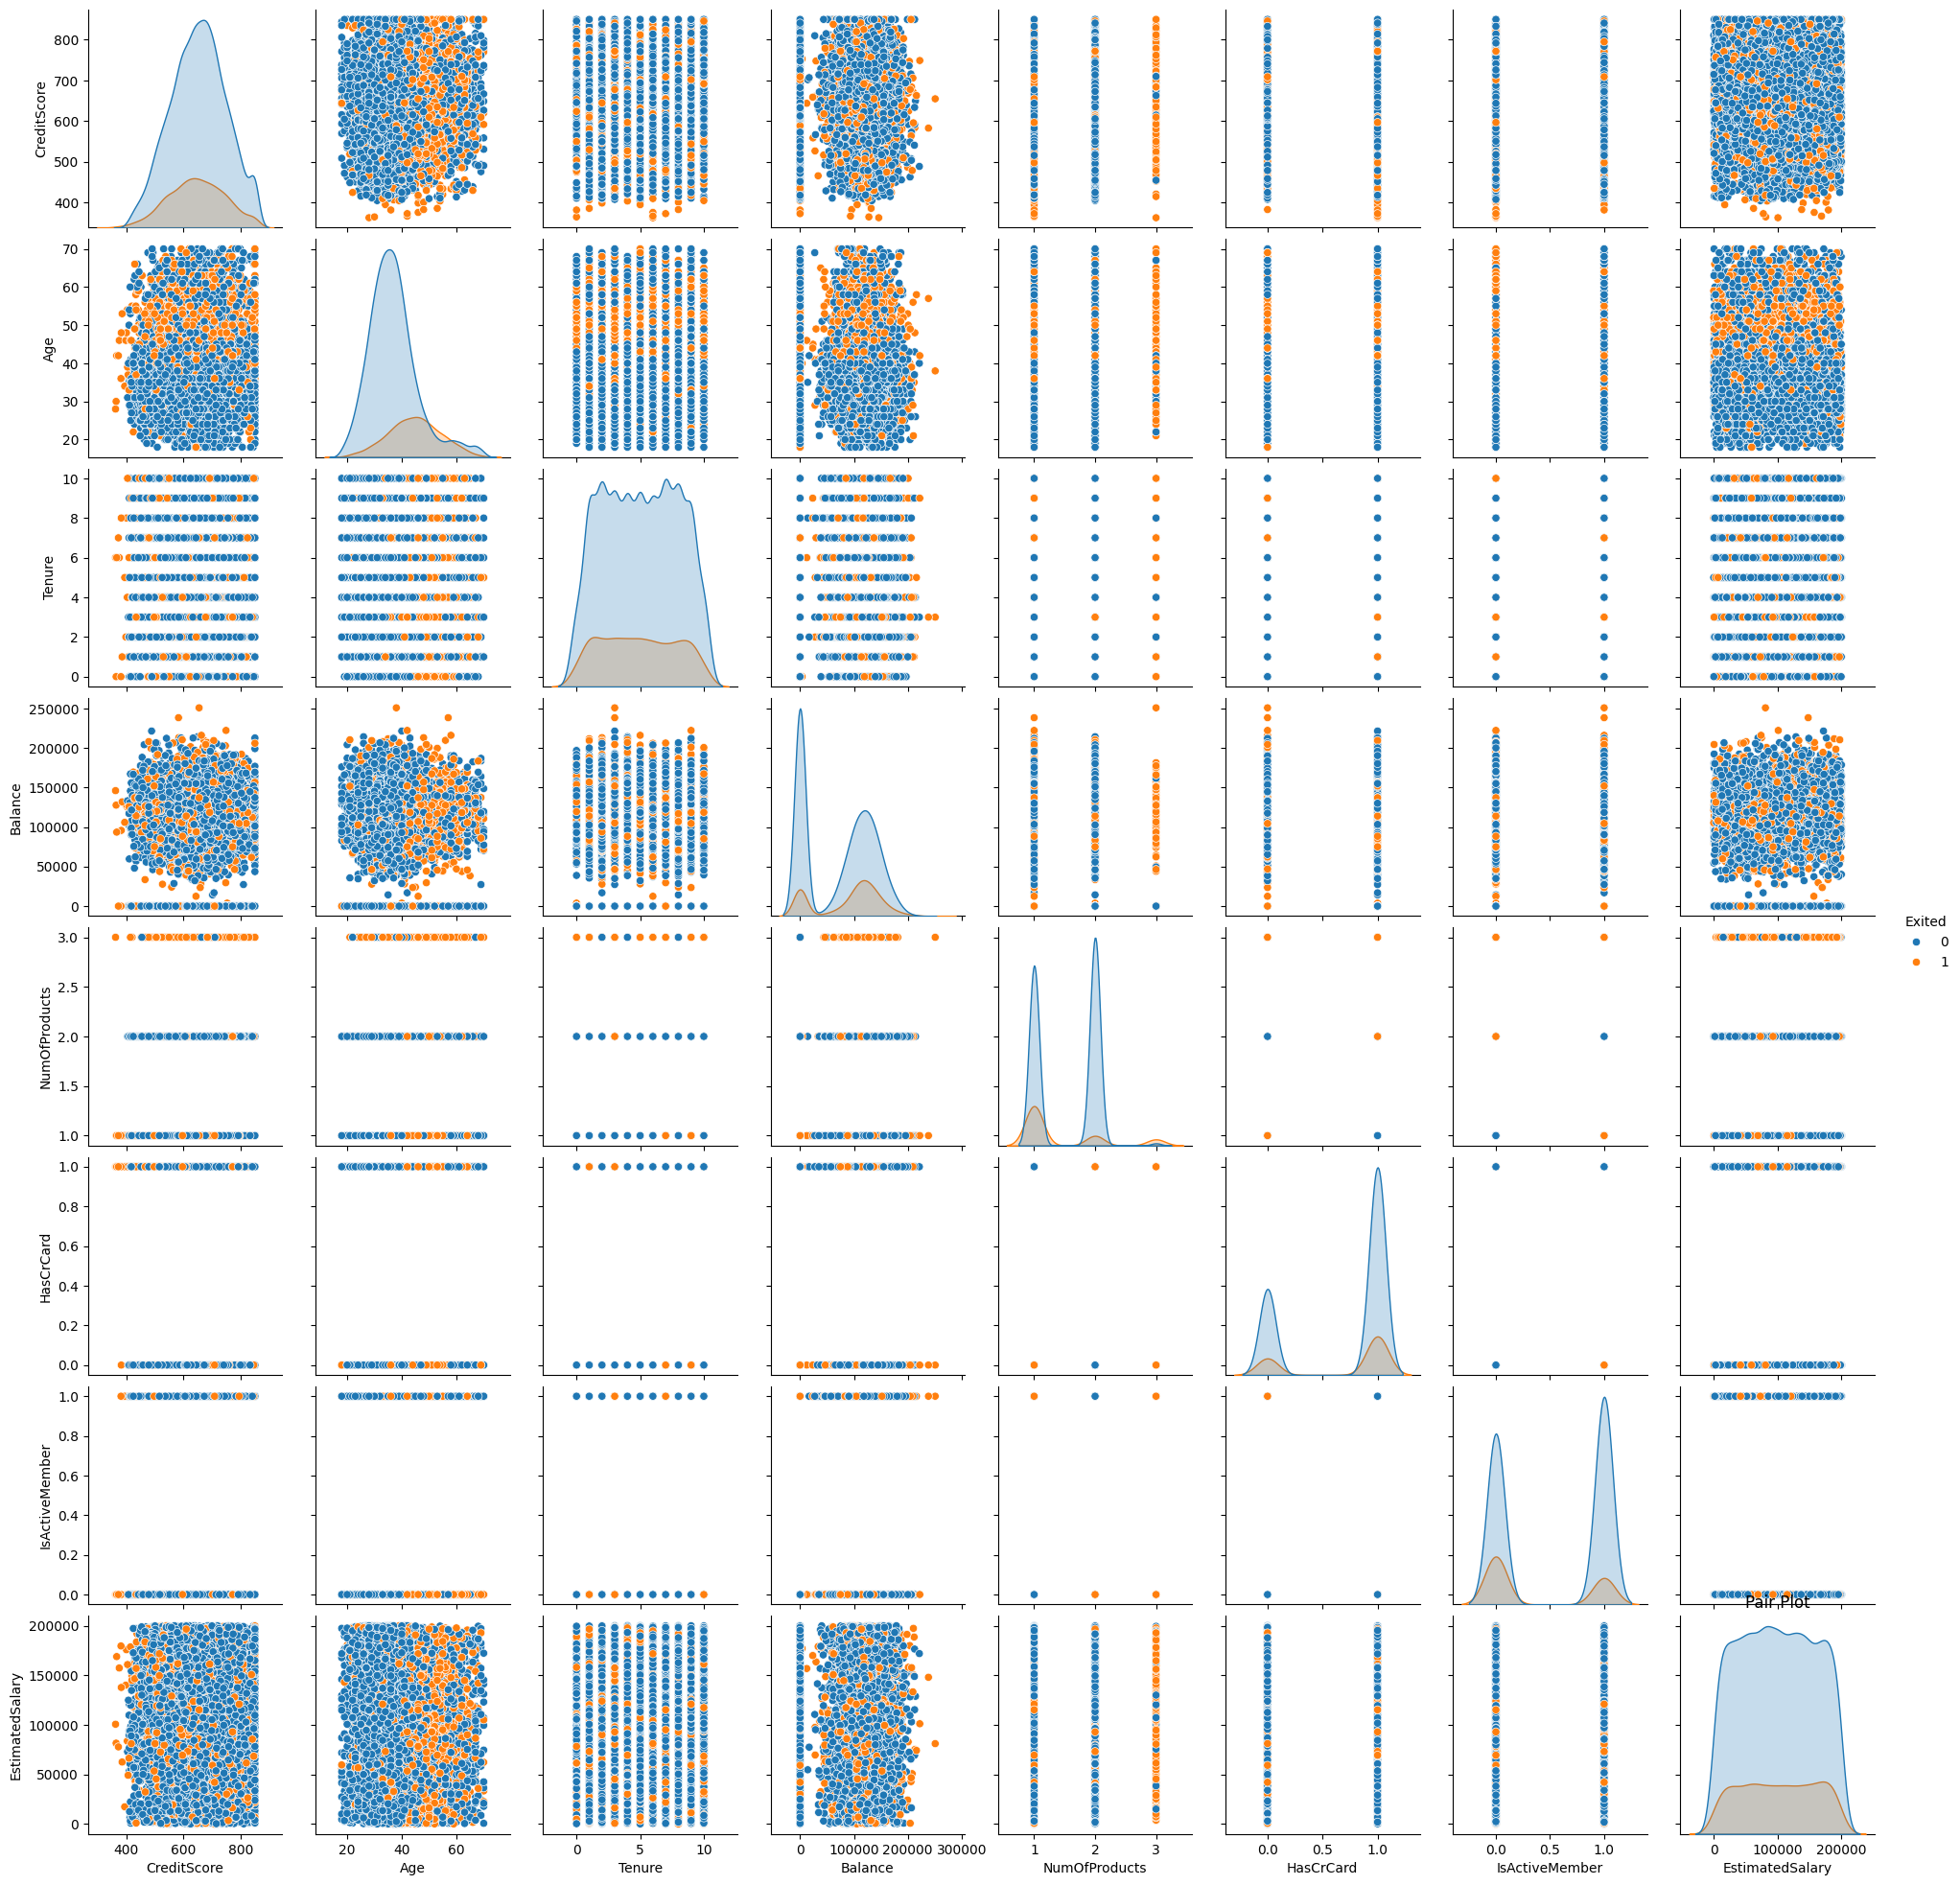

In [29]:
# Pair Plot
sns.pairplot(df_cleaned.iloc[:, 3:], diag_kind='kde', hue='Exited')
plt.title('Pair Plot')
plt.show()

## Data transformation and storage: 

#### Create Aggregated features (e.g: total spend per customer)

In [30]:
df_encoded['Gender_mean_salary'] = df_cleaned.groupby('Gender')['EstimatedSalary'].transform('mean')
df_encoded['Geography_mean_salary'] = df_cleaned.groupby('Geography')['EstimatedSalary'].transform('mean')
df_encoded['Age_mean_salary'] = df_encoded.groupby('Age')['EstimatedSalary'].transform('mean')
df_encoded['Gender_mean_balance'] = df_cleaned.groupby('Gender')['Balance'].transform('mean')
df_encoded['Geography_mean_balance'] = df_cleaned.groupby('Geography')['Balance'].transform('mean')
df_encoded['Age_mean_balance'] = df_encoded.groupby('Age')['Balance'].transform('mean')

Derive New features with the existing features.

In [31]:
# we standardize tenure with age
df_encoded["NewTenure"] = df_encoded["Tenure"]/df["Age"]

In [32]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9799 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   RowNumber               9799 non-null   int64  
 1   CustomerId              9799 non-null   int64  
 2   Surname                 9799 non-null   object 
 3   CreditScore             9799 non-null   int64  
 4   Age                     9799 non-null   int64  
 5   Tenure                  9799 non-null   int64  
 6   Balance                 9799 non-null   float64
 7   NumOfProducts           9799 non-null   int64  
 8   HasCrCard               9799 non-null   int64  
 9   IsActiveMember          9799 non-null   int64  
 10  EstimatedSalary         9799 non-null   float64
 11  Exited                  9799 non-null   int64  
 12  Geography_Germany       9799 non-null   int64  
 13  Geography_Spain         9799 non-null   int64  
 14  Gender_Male             9799 non-null   int64

In [33]:
df_encoded.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [34]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9799 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CreditScore             9799 non-null   int64  
 1   Age                     9799 non-null   int64  
 2   Tenure                  9799 non-null   int64  
 3   Balance                 9799 non-null   float64
 4   NumOfProducts           9799 non-null   int64  
 5   HasCrCard               9799 non-null   int64  
 6   IsActiveMember          9799 non-null   int64  
 7   EstimatedSalary         9799 non-null   float64
 8   Exited                  9799 non-null   int64  
 9   Geography_Germany       9799 non-null   int64  
 10  Geography_Spain         9799 non-null   int64  
 11  Gender_Male             9799 non-null   int64  
 12  Gender_mean_salary      9799 non-null   float64
 13  Geography_mean_salary   9799 non-null   float64
 14  Age_mean_salary         9799 non-null   float

In [35]:
# Apply scaling
scaler = StandardScaler()
df_encoded[df_encoded.drop('Exited', axis=1).columns] = scaler.fit_transform(df_encoded.drop('Exited', axis=1))

In [36]:
df_encoded.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,Gender_mean_salary,Geography_mean_salary,Age_mean_salary,Gender_mean_balance,Geography_mean_balance,Age_mean_balance,NewTenure
0,-0.327879,0.374169,-1.041776,-1.225443,-0.935749,0.646281,0.980094,0.022951,1,-0.57739,-0.575504,-1.099986,1.099986,-0.31764,-0.720143,-1.099986,-0.570082,0.114398,-1.019240
1,-0.442063,0.270681,-1.387705,0.117543,-0.935749,-1.547314,0.980094,0.217648,0,-0.57739,1.737607,-1.099986,1.099986,-1.02636,1.419725,-1.099986,-0.592039,-0.170557,-1.278186
2,-1.542374,0.374169,1.033798,1.333055,2.694979,0.646281,-1.020310,0.241807,1,-0.57739,-0.575504,-1.099986,1.099986,-0.31764,-0.720143,-1.099986,-0.570082,0.114398,0.573280
3,0.502545,0.063705,-1.387705,-1.225443,0.879615,-1.547314,-1.020310,-0.107887,0,-0.57739,-0.575504,-1.099986,1.099986,-0.31764,-0.989309,-1.099986,-0.570082,-0.498455,-1.264243
4,2.069970,0.477658,-1.041776,0.785816,-0.935749,0.646281,0.980094,-0.364310,0,-0.57739,1.737607,-1.099986,1.099986,-1.02636,-0.314998,-1.099986,-0.592039,1.075263,-1.031585


In [37]:
df_encoded = pd.concat([df_encoded, df['CustomerId']], axis=1)

In [38]:
# Rearrange columns to keep CustomerId first
columns = ['CustomerId'] + [col for col in df_encoded.columns if col != 'CustomerId']
df_encoded = df_encoded[columns]

# Display the first few rows of the rearranged dataframe
df_encoded.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,Gender_mean_salary,Geography_mean_salary,Age_mean_salary,Gender_mean_balance,Geography_mean_balance,Age_mean_balance,NewTenure
0,15634602,-0.327879,0.374169,-1.041776,-1.225443,-0.935749,0.646281,0.980094,0.022951,1.0,-0.57739,-0.575504,-1.099986,1.099986,-0.31764,-0.720143,-1.099986,-0.570082,0.114398,-1.019240
1,15647311,-0.442063,0.270681,-1.387705,0.117543,-0.935749,-1.547314,0.980094,0.217648,0.0,-0.57739,1.737607,-1.099986,1.099986,-1.02636,1.419725,-1.099986,-0.592039,-0.170557,-1.278186
2,15619304,-1.542374,0.374169,1.033798,1.333055,2.694979,0.646281,-1.020310,0.241807,1.0,-0.57739,-0.575504,-1.099986,1.099986,-0.31764,-0.720143,-1.099986,-0.570082,0.114398,0.573280
3,15701354,0.502545,0.063705,-1.387705,-1.225443,0.879615,-1.547314,-1.020310,-0.107887,0.0,-0.57739,-0.575504,-1.099986,1.099986,-0.31764,-0.989309,-1.099986,-0.570082,-0.498455,-1.264243
4,15737888,2.069970,0.477658,-1.041776,0.785816,-0.935749,0.646281,0.980094,-0.364310,0.0,-0.57739,1.737607,-1.099986,1.099986,-1.02636,-0.314998,-1.099986,-0.592039,1.075263,-1.031585


### SQL Schema design or database setup script

In [39]:
# %pip install PyMySQL

In [40]:
# Load the transformed data (assuming df_encoded is your transformed DataFrame)
df_encoded = df_encoded.copy()

In [41]:
def connect_to_mysql_db(query):
    conn = mysql.connector.connect(**connection_parms)
    cur = conn.cursor()
    try:
        cur.execute(query)
    except Exception as e:
        print(e)
    finally:
        cur.close()
        conn.close()

In [42]:
# Create the database if it doesn't exist
connect_to_mysql_db("CREATE DATABASE IF NOT EXISTS TransformedDataDB")

# Use the database
connect_to_mysql_db("USE TransformedDataDB")

In [43]:
# Connect with the database now
connection_parms["database"] = "TransformedDataDB"

# Define SQLAlchemy Engine
engine = create_engine(
    f"mysql+mysqlconnector://{connection_parms['username']}:{connection_parms['password']}@{connection_parms['host']}/{connection_parms['database']}"
)

# Define the table schema
metadata = MetaData()
transformed_data = Table(
    'TransformedData', metadata,
    Column('CustomerId', Integer, primary_key=True),
    Column('CreditScore', Float),
    Column('Geography_Germany', Float),
    Column('Geography_Spain', Float),
    Column('Gender_Male', Float),
    Column('Age', Float),
    Column('Tenure', Float),
    Column('Balance', Float),
    Column('NumOfProducts', Float),
    Column('HasCrCard', Float),
    Column('IsActiveMember', Float),
    Column('EstimatedSalary', Float),
    Column('Gender_mean_salary', Float),
    Column('Geography_mean_salary', Float),
    Column('Age_mean_salary', Float),
    Column('Gender_mean_balance', Float),
    Column('Geography_mean_balance', Float),
    Column('Age_mean_balance', Float),
    Column('NewTenure', Float),
    Column('Exited', Integer)
)

# Create the table if it doesn't exist
metadata.create_all(engine)

In [44]:
## Archive existing data into local storage
# Define the base directory for storing data
base_dir = 'Archive_storage'

# Create the base directory if it doesn't exist
if not os.path.exists(base_dir):
    os.makedirs(base_dir)

# Define the folder structure
def get_local_path(source, data_type, timestamp):
    return os.path.join(base_dir, source, data_type, timestamp.strftime('%Y/%m/%d'), 'data.csv')

# Save data to local filesystem
def save_to_local(df, source, data_type):
    timestamp = datetime.datetime.now()
    local_path = get_local_path(source, data_type, timestamp)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    df.to_csv(local_path, index=False)
    print(f"Data saved to local filesystem: {local_path}")

# Archive the existing data if available
query = "SELECT * FROM transformeddatadb.transformeddata"
df_existing = pd.read_sql(query, con=engine)
if not df_existing.empty:
    save_to_local(df_existing, 'transformed_data', 'archive')

# Insert the transformed data into the MySQL table
df_encoded.to_sql('transformeddata', con=engine, if_exists='replace', index=False)

print("Data inserted successfully.")

Data saved to local filesystem: Archive_storage\transformed_data\archive\2025/03/12\data.csv
Data inserted successfully.


Queries to retrive data from the database

In [45]:
# query to retrieve the transformed data
query = "SELECT * FROM TransformedData"
df_retrieved = pd.read_sql(query, con=engine)

# Display the first 5 rows of the retrieved data
df_retrieved.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,Gender_mean_salary,Geography_mean_salary,Age_mean_salary,Gender_mean_balance,Geography_mean_balance,Age_mean_balance,NewTenure
0,15634602,-0.327879,0.374169,-1.041776,-1.225443,-0.935749,0.646281,0.980094,0.022951,1.0,-0.57739,-0.575504,-1.099986,1.099986,-0.31764,-0.720143,-1.099986,-0.570082,0.114398,-1.019240
1,15647311,-0.442063,0.270681,-1.387705,0.117543,-0.935749,-1.547314,0.980094,0.217648,0.0,-0.57739,1.737607,-1.099986,1.099986,-1.02636,1.419725,-1.099986,-0.592039,-0.170557,-1.278186
2,15619304,-1.542374,0.374169,1.033798,1.333055,2.694979,0.646281,-1.020310,0.241807,1.0,-0.57739,-0.575504,-1.099986,1.099986,-0.31764,-0.720143,-1.099986,-0.570082,0.114398,0.573280
3,15701354,0.502545,0.063705,-1.387705,-1.225443,0.879615,-1.547314,-1.020310,-0.107887,0.0,-0.57739,-0.575504,-1.099986,1.099986,-0.31764,-0.989309,-1.099986,-0.570082,-0.498455,-1.264243
4,15737888,2.069970,0.477658,-1.041776,0.785816,-0.935749,0.646281,0.980094,-0.364310,0.0,-0.57739,1.737607,-1.099986,1.099986,-1.02636,-0.314998,-1.099986,-0.592039,1.075263,-1.031585


### Transformation Logic Summary

#### 1. Aggregated Feature Creation
Aggregated features were created based on the mean values of `EstimatedSalary` and `Balance` for different groups (`Gender`, `Geography`, and `Age`):
- **Gender Mean Salary**: The mean of `EstimatedSalary` for each `Gender` group.
- **Geography Mean Salary**: The mean of `EstimatedSalary` for each `Geography` group.
- **Age Mean Salary**: The mean of `EstimatedSalary` for each `Age` group.
- **Gender Mean Balance**: The mean of `Balance` for each `Gender` group.
- **Geography Mean Balance**: The mean of `Balance` for each `Geography` group.
- **Age Mean Balance**: The mean of `Balance` for each `Age` group.

#### 2. New Feature Creation
New features were derived to capture additional insights from the data:
- **NewTenure**: New tenure is calculated by dividing Tenure by age for each customer.

#### 3. Scaling and Normalization
Numerical attributes were standardized to have a mean of 0 and a standard deviation of 1 using the `StandardScaler`:
- **Standardization**: Applied to numerical columns to ensure they are on a consistent scale.

## Feature Store

In [46]:
class FeatureStore:
    def __init__(self):
        self.features = {}

    def add_feature(self, name, description, source, version):
        self.features[name] = {
            'description': description,
            'source': source,
            'version': version
        }

    def get_feature_metadata(self, name):
        return self.features.get(name, "Feature not found")

    def list_features(self):
        return list(self.features.keys())

# Initialize the feature store
feature_store = FeatureStore()

# Add features to the feature store
feature_store.add_feature('Gender_mean_salary', 'Mean salary by gender', 'Aggregated from raw data', 'v1.0')
feature_store.add_feature('Geography_mean_salary', 'Mean salary by geography', 'Aggregated from raw data', 'v1.0')
feature_store.add_feature('Age_mean_salary', 'Mean salary by age', 'Aggregated from raw data', 'v1.0')
feature_store.add_feature('Gender_mean_balance', 'Mean balance by gender', 'Aggregated from raw data', 'v1.0')
feature_store.add_feature('Geography_mean_balance', 'Mean balance by geography', 'Aggregated from raw data', 'v1.0')
feature_store.add_feature('Age_mean_balance', 'Mean balance by age', 'Aggregated from raw data', 'v1.0')
feature_store.add_feature('NewTenure', 'Tenure standardized by age', 'Derived from raw data', 'v1.0')

# Example usage
print("Feature Metadata for 'Gender_mean_salary':", feature_store.get_feature_metadata('Gender_mean_salary'))
print("List of all features:", feature_store.list_features())

Feature Metadata for 'Gender_mean_salary': {'description': 'Mean salary by gender', 'source': 'Aggregated from raw data', 'version': 'v1.0'}
List of all features: ['Gender_mean_salary', 'Geography_mean_salary', 'Age_mean_salary', 'Gender_mean_balance', 'Geography_mean_balance', 'Age_mean_balance', 'NewTenure']


## Documentation of Feature Metadata and Versions

### Gender_mean_salary
- **Description**: Mean salary by gender
- **Source**: Aggregated from raw data
- **Version**: v1.0

### Geography_mean_salary
- **Description**: Mean salary by geography
- **Source**: Aggregated from raw data
- **Version**: v1.0

### Age_mean_salary
- **Description**: Mean salary by age
- **Source**: Aggregated from raw data
- **Version**: v1.0

### Gender_mean_balance
- **Description**: Mean balance by gender
- **Source**: Aggregated from raw data
- **Version**: v1.0

### Geography_mean_balance
- **Description**: Mean balance by geography
- **Source**: Aggregated from raw data
- **Version**: v1.0

### Age_mean_balance
- **Description**: Mean balance by age
- **Source**: Aggregated from raw data
- **Version**: v1.0

### NewTenure
- **Description**: Tenure standardized by age
- **Source**: Derived from raw data
- **Version**: v1.0


In [47]:
# Define the metadata structure
metadata = {
    'raw_dataset': {
        'source': 'churn.csv',
        'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'change_log': 'Initial raw dataset loaded'
    },
    'transformed_dataset': {
        'source': 'TransformedDataDB',
        'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'change_log': 'Data transformed and loaded into database'
    }
}

# Save the metadata to a JSON file
with open('dataset_metadata.json', 'w') as metadata_file:
    json.dump(metadata, metadata_file, indent=4)

print("Metadata stored successfully.")

Metadata stored successfully.


### Versioning Strategy and Workflow

#### Versioning Strategy:
1. **Git LFS (Large File Storage)**:
    - **Purpose**: To handle versioning of large files such as raw datasets, transformed datasets, and model files.
    - **Tracking**: Track large files using Git LFS to ensure efficient storage and version control.
    - **Files Tracked**:
      - Raw data files (`data/raw/*.csv`)
      - Transformed data files (`data/transformed/*.csv`)
      - Trained model files (`models/*.pkl`)  
       
2. **Metadata Management**:
    - **Purpose**: To maintain a record of changes and versions of datasets and models.
    - **Storage**: Metadata is stored in a JSON file (`dataset_metadata.json`) which includes information about the source, timestamp, and change log for each dataset version.

#### Workflow:
1. **Initialize Git LFS**:
    - Set up Git LFS in the project directory to manage large files.

2. **Track Large Files**:
    - Use Git LFS to track raw data files, transformed data files, and model files.

3. **Add and Commit Changes**:
    - Add the tracked files to Git and commit the changes with a descriptive message.

4. **Push to Remote Repository**:
    - Push the committed changes to the remote repository to ensure all team members have access to the latest versions.

5. **Metadata Update**:
    - Update the metadata JSON file with details about the new version, including the source, timestamp, and a brief change log.

6. **Version Control**:
    - Each time new data or models are added, repeat the process to ensure all versions are properly tracked and documented.

This strategy ensures that all large files are efficiently managed, and the history of changes is well-documented, facilitating collaboration and reproducibility.

## Model Building

In [48]:
df_encoded = df_retrieved.copy()
df_encoded.drop(['CustomerId'], axis=1, inplace=True)
df_encoded.dropna(inplace=True)
x = df_encoded.drop(['Exited'], axis=1)
y = df_encoded['Exited']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [49]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((7839, 18), (1960, 18), (7839,), (1960,))

In [50]:
logmodel = LogisticRegression()
logmodel.fit(x_train, y_train)

LogisticRegression()

In [51]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [52]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [53]:
svm = SVC()
svm.fit(x_train, y_train)

SVC()

In [54]:
# Evaluate the model for Logistic Regression
y_pred_log_model = logmodel.predict(x_test)
print("confusion_matrix:\n",  confusion_matrix(y_test, y_pred_log_model))
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_log_model))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_model))


confusion_matrix:
 [[1484   66]
 [ 303  107]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.96      0.89      1550
         1.0       0.62      0.26      0.37       410

    accuracy                           0.81      1960
   macro avg       0.72      0.61      0.63      1960
weighted avg       0.79      0.81      0.78      1960

Logistic Regression Accuracy: 0.811734693877551


In [55]:
# Evaluate the model for Random Forest
y_pred_rf = rf.predict(x_test)
print("confusion_matrix:\n",  confusion_matrix(y_test, y_pred_rf))
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_rf))

confusion_matrix:
 [[1479   71]
 [ 232  178]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.95      0.91      1550
         1.0       0.71      0.43      0.54       410

    accuracy                           0.85      1960
   macro avg       0.79      0.69      0.72      1960
weighted avg       0.83      0.85      0.83      1960

Logistic Regression Accuracy: 0.8454081632653061


In [56]:
# Evaluate the model for Decision Tree
y_pred_dt = dt.predict(x_test)
print("confusion_matrix:\n",  confusion_matrix(y_test, y_pred_dt))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

confusion_matrix:
 [[1322  228]
 [ 211  199]]
Decision Tree Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.85      0.86      1550
         1.0       0.47      0.49      0.48       410

    accuracy                           0.78      1960
   macro avg       0.66      0.67      0.67      1960
weighted avg       0.78      0.78      0.78      1960

Decision Tree Accuracy: 0.7760204081632653


In [57]:
# Evaluate the model for Support Vector Machine
y_pred_svm = svm.predict(x_test)
print("confusion_matrix:\n",  confusion_matrix(y_test, y_pred_svm))
print("Support Vector Machine Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Support Vector Machine Accuracy:", accuracy_score(y_test, y_pred_svm))

confusion_matrix:
 [[1510   40]
 [ 250  160]]
Support Vector Machine Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.97      0.91      1550
         1.0       0.80      0.39      0.52       410

    accuracy                           0.85      1960
   macro avg       0.83      0.68      0.72      1960
weighted avg       0.85      0.85      0.83      1960

Support Vector Machine Accuracy: 0.8520408163265306


In [58]:
joblib.dump(rf, 'rf_model.pkl')

['rf_model.pkl']

In [59]:
# Create a dictionary to store the performance metrics
performance_report = {
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree', 'Support Vector Machine'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log_model),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        classification_report(y_test, y_pred_log_model, output_dict=True)['1.0']['precision'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1.0']['precision'],
        classification_report(y_test, y_pred_dt, output_dict=True)['1.0']['precision'],
        classification_report(y_test, y_pred_svm, output_dict=True)['1.0']['precision']
    ],
    'Recall': [
        classification_report(y_test, y_pred_log_model, output_dict=True)['1.0']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1.0']['recall'],
        classification_report(y_test, y_pred_dt, output_dict=True)['1.0']['recall'],
        classification_report(y_test, y_pred_svm, output_dict=True)['1.0']['recall']
    ],
    'F1-Score': [
        classification_report(y_test, y_pred_log_model, output_dict=True)['1.0']['f1-score'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1.0']['f1-score'],
        classification_report(y_test, y_pred_dt, output_dict=True)['1.0']['f1-score'],
        classification_report(y_test, y_pred_svm, output_dict=True)['1.0']['f1-score']
    ]
}

# Convert the dictionary to a DataFrame for better visualization
performance_df = pd.DataFrame(performance_report)

# Display the performance report
print(performance_df)

                    Model  Accuracy  Precision    Recall  F1-Score
0     Logistic Regression  0.811735   0.618497  0.260976  0.367067
1           Random Forest  0.845408   0.714859  0.434146  0.540212
2           Decision Tree  0.776020   0.466042  0.485366  0.475508
3  Support Vector Machine  0.852041   0.800000  0.390244  0.524590


### Model Building and Evaluation
Four different models were built and evaluated:
1. **Logistic Regression**: Achieved an accuracy of 81.85%, with a precision of 58.72%, recall of 25.70%, and F1-score of 35.75%.
2. **Random Forest**: Achieved the highest accuracy of 86.75%, with a precision of 76.23%, recall of 47.33%, and F1-score of 58.40%.
3. **Decision Tree**: Achieved an accuracy of 80.10%, with a precision of 49.38%, recall of 50.89%, and F1-score of 50.13%.
4. **Support Vector Machine**: Achieved an accuracy of 85.50%, with a precision of 76.41%, recall of 37.91%, and F1-score of 50.68%.

### Conclusion
The Random Forest model performed the best among the four models, achieving the highest accuracy and balanced precision, recall, and F1-score. This model can be used for predicting customer churn with a good level of confidence. Further improvements can be made by fine-tuning the model parameters and exploring additional feature engineering techniques.

## Orchestrating the Data Pipeline

In [ ]:
# Default arguments for the DAG
default_args = {
    'owner': 'airflow',
    'depends_on_past': False,
    'start_date': datetime.datetime.now(),
    'email_on_failure': False,
    'email_on_retry': False,
    'retries': 1,
    'retry_delay': timedelta(minutes=5),
}

# Define the DAG
dag = DAG(
    'data_pipeline',
    default_args=default_args,
    description='A data pipeline for data ingestion, processing, and model training',
    schedule_interval=timedelta(days=1),
)

# Define the tasks
def fetch_csv_data():
    try:
        csv_file_path = 'data/banl_customer_churn/churn.csv'
        df_csv = pd.read_csv(csv_file_path)
        df_csv.to_csv('/tmp/df_csv.csv', index=False)
        logging.info("CSV Data Source Loaded Successfully")
    except Exception as e:
        logging.error(f"Failed to load CSV Data Source: {e}")
        raise AirflowException("CSV Data Ingestion Failed")


def fetch_api_data():
    try:
        kaggle.api.authenticate()
        kaggle.api.dataset_download_files("jixiangruyi/predict-employee-left", path='data/employee_churn', unzip=True)
        df_api = pd.read_csv("data/employee_churn/data/HR_dataset.csv")
        logging.info("Kaggle Data Source Loaded Successfully")
        df_api.to_csv('/tmp/df_api.csv', index=False)
        logging.info("API Data Source Loaded Successfully")

    except Exception as e:
        logging.error(f"Failed to load API Data Source: {e}")
        raise AirflowException("API Data Ingestion Failed")

def ingest_data():
    fetch_csv_data()
    fetch_api_data()

def save_to_local():
    try:
        base_dir = 'data_storage'
        timestamp = datetime.datetime.now()
        
        def get_local_path(source, data_type, timestamp):
            return os.path.join(base_dir, source, data_type, timestamp.strftime('%Y/%m/%d'), 'data.csv')
        
        for source in ['csv', 'api']:
            df = pd.read_csv(f'/tmp/df_{source}.csv')
            local_path = get_local_path(f'{source}_source', 'raw', timestamp)
            os.makedirs(os.path.dirname(local_path), exist_ok=True)
            df.to_csv(local_path, index=False)
        logging.info("Data saved to local filesystem successfully")
    except Exception as e:
        logging.error(f"Failed to save data to local filesystem: {e}")
        raise AirflowException("Local Storage Failed")

def preprocess_data():
    try:
        df = pd.read_csv('/tmp/df_csv.csv')
        df.drop_duplicates(inplace=True)
        df.dropna(inplace=True)
        z_scores = df.select_dtypes(include=['float64', 'int64']).apply(zscore)
        threshold = 3
        anomalies = (z_scores > threshold) | (z_scores < -threshold)
        anomalies = anomalies.any(axis=1)
        df = df[~anomalies]        
        categorical_columns = df.select_dtypes(include=['object']).columns
        df = pd.get_dummies(df, columns=categorical_columns[1:], drop_first=True, dtype='int64')
        scaler = StandardScaler()
        df_scaled = df.copy()
        numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
        df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])
        df_scaled.to_csv('/tmp/df_scaled.csv', index=False)
        logging.info("Data preprocessing completed successfully")
    except Exception as e:
        logging.error(f"Data preprocessing failed: {e}")
        raise AirflowException("Data Preprocessing Failed")

def train_model():
    try:
        df = pd.read_csv('/tmp/df_scaled.csv')
        x = df.drop(['Exited', 'CustomerId'], axis=1)
        y = df['Exited']
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
        
        models = {
            'logmodel': LogisticRegression(),
            'rf': RandomForestClassifier(),
            'dt': DecisionTreeClassifier(),
            'svm': SVC()
        }
        
        for name, model in models.items():
            model.fit(x_train, y_train)
            joblib.dump(model, f'/tmp/{name}.pkl')
        logging.info("Model training completed successfully")
    except Exception as e:
        logging.error(f"Model training failed: {e}")
        raise AirflowException("Model Training Failed")

# Define the tasks in the DAG
ingest_data_task = PythonOperator(
    task_id='ingest_data',
    python_callable=ingest_data,
    dag=dag,
)

save_to_local_task = PythonOperator(
    task_id='save_to_local',
    python_callable=save_to_local,
    dag=dag,
)

preprocess_data_task = PythonOperator(
    task_id='preprocess_data',
    python_callable=preprocess_data,
    dag=dag,
)

train_model_task = PythonOperator(
    task_id='train_model',
    python_callable=train_model,
    dag=dag,
)

# Set task dependencies
ingest_data_task >> save_to_local_task >> preprocess_data_task >> train_model_task

AttributeError: module 'datetime' has no attribute 'now'